# T=1.5

Data saved as: ising_data/ising_configurations_T1.5_L128.npy


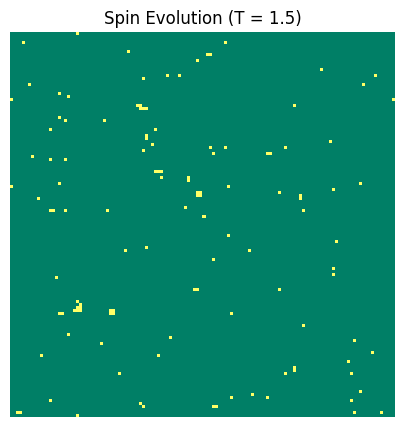

GIF saved as 'wolff_ising_simulation_T1.5_L128.gif'


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# Model parameters
L = 128  # lattice size
T = 1.5  # temperature
J = 1    # coupling constant

beta = 1 / T
p = 1 - np.exp(-2 * beta * J)
n_steps = 1000

# Generate random spin configuration on LxL lattice
spins = np.random.choice([-1, 1], size=(L, L))

# Function to select cross-shaped nearest neighbors
def neighbors(i, j, L):
    return [((i + 1) % L, j),
            ((i - 1) % L, j),
            (i, (j + 1) % L),
            (i, (j - 1) % L)]

# Wolff algorithm
def wolff_cluster_flip(spins, L, p):
    i, j = np.random.randint(0, L, size=2)
    cluster = {(i, j)}
    frontier = [(i, j)]
    original_spin = spins[i, j]
    while frontier:
        x, y = frontier.pop()
        for nx, ny in neighbors(x, y, L):
            if (nx, ny) not in cluster and spins[nx, ny] == original_spin:
                if np.random.rand() < p:
                    cluster.add((nx, ny))
                    frontier.append((nx, ny))
    for x, y in cluster:
        spins[x, y] *= -1
    return spins

# Initialize lists for GIF and final states
frames = []
final_state_samples = []
frame_interval = 30
save_interval = 25  # save a sample every 25 steps

# Main simulation loop
for step in range(n_steps):
    wolff_cluster_flip(spins, L, p)

    if step % frame_interval == 0:
        frames.append(spins.copy())

    if step > 10 and step % save_interval == 0:
        final_state_samples.append(spins.copy())

# Save final samples as .npy file
output_path = "ising_data"
os.makedirs(output_path, exist_ok=True)
file_name = os.path.join(output_path, f"ising_configurations_T{T}_L{L}.npy")
np.save(file_name, np.array(final_state_samples))
print(f"Data saved as: {file_name}")

# Create and save animation GIF
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0], cmap="summer", animated=True)
ax.set_title(f"Spin Evolution (T = {T})")
plt.axis("off")

def update(frame):
    im.set_array(frames[frame])
    return [im]
ani = FuncAnimation(fig, update, frames=len(frames), interval=200, blit=True)
gif_path = f"wolff_ising_simulation_T{T}_L{L}.gif"
ani.save(gif_path, writer=PillowWriter(fps=5))
plt.show()
print(f"GIF saved as '{gif_path}'")

Training for phase: critical
Pre-training layer 1...
Epoch 1 (layer 1), Loss: 6569.1362
Epoch 2 (layer 1), Loss: 335.5644
Epoch 3 (layer 1), Loss: -191.2838
Epoch 4 (layer 1), Loss: -1213.8414
Epoch 5 (layer 1), Loss: 1771.2849
Epoch 6 (layer 1), Loss: 1082.8035
Epoch 7 (layer 1), Loss: 1096.9303
Epoch 8 (layer 1), Loss: -1032.3433
Epoch 9 (layer 1), Loss: -730.8438
Epoch 10 (layer 1), Loss: -843.4655
Epoch 11 (layer 1), Loss: -1025.0133
Epoch 12 (layer 1), Loss: -936.3643
Epoch 13 (layer 1), Loss: -778.3045
Epoch 14 (layer 1), Loss: 99.5520
Epoch 15 (layer 1), Loss: -1132.9512
Epoch 16 (layer 1), Loss: -731.1695
Epoch 17 (layer 1), Loss: -863.1982
Epoch 18 (layer 1), Loss: -809.5812
Epoch 19 (layer 1), Loss: -549.0280
Epoch 20 (layer 1), Loss: -791.3699
Epoch 21 (layer 1), Loss: -742.9591
Epoch 22 (layer 1), Loss: -723.3762
Epoch 23 (layer 1), Loss: -838.5071
Epoch 24 (layer 1), Loss: -701.9945
Epoch 25 (layer 1), Loss: -759.1115
Epoch 26 (layer 1), Loss: -989.3096
Epoch 27 (layer 1),

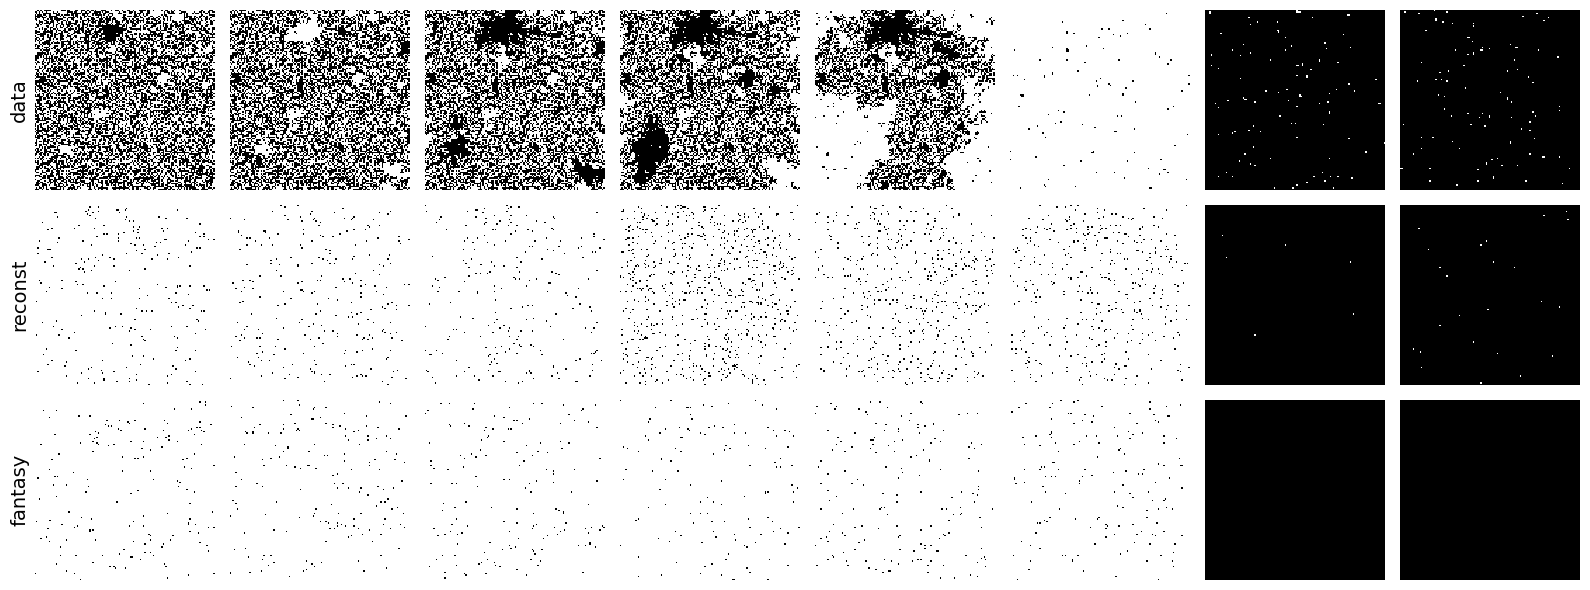

Saved in: ising_data/DBM_ising_training_data_T1.5_L=128.npy


In [38]:
# Grid size
L = 128

# Grid parameters
image_shape = (L, L)
n_visible = L * L
num_to_plot = 8

batch_size = 15
num_epochs = 100
monte_carlo_steps = 5
num_fantasy_steps = 50
num_hidden_units = [1024, 64]  # Adjusted proportionally to L increase

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RBM class
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))

    def sample_h(self, v):
        prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return torch.bernoulli(prob), prob

    def sample_v(self, h):
        prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return torch.bernoulli(prob), prob

    def forward(self, v, k=1):
        v_k = v
        for _ in range(k):
            h_prob = torch.sigmoid(F.linear(v_k, self.W, self.h_bias))
            v_prob = torch.sigmoid(F.linear(h_prob, self.W.t(), self.v_bias))
            v_k = v_prob  # keep gradients
        return v, v_k

# Contrastive Divergence Loss - CORRIGIDO: adicionado termo h_bias faltante
def contrastive_divergence_loss(v0, vk, h0, hk, rbm):
    # Energia RBM completa: E = -v·W·h - v·v_bias - h·h_bias
    energy_vh_data = torch.matmul(v0, rbm.W.t()) * h0
    E_data = -torch.sum(energy_vh_data, dim=1) - torch.sum(v0 * rbm.v_bias, dim=1) - torch.sum(h0 * rbm.h_bias, dim=1)
    
    energy_vh_model = torch.matmul(vk, rbm.W.t()) * hk
    E_model = -torch.sum(energy_vh_model, dim=1) - torch.sum(vk * rbm.v_bias, dim=1) - torch.sum(hk * rbm.h_bias, dim=1)
    
    return torch.mean(E_data - E_model)

# Model training
def train_model(model, data_loader, num_epochs, steps):
    rbm1, rbm2 = model
    device = next(rbm1.parameters()).device
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.007)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    
    print("Pre-training layer 1...")
    rbm1.train()
    for epoch in range(num_epochs):
        for batch, in data_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad()
            loss.backward()
            optim1.step()
        print(f"Epoch {epoch+1} (layer 1), Loss: {loss.item():.4f}")

    print("Pre-training layer 2...")
    rbm2.train()
    with torch.no_grad():
        all_h, _ = rbm1.sample_h(torch.cat([b[0].to(device) for b in data_loader]))
    dataset_h = TensorDataset(all_h)
    loader_h = DataLoader(dataset_h, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        for batch, in loader_h:
            h0 = batch.to(device)
            h0_sample, _ = rbm2.sample_h(h0)
            vk, _ = rbm2.sample_v(h0_sample)
            hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_sample, hk, rbm2)
            optim2.zero_grad()
            loss.backward()
            optim2.step()
        print(f"Epoch {epoch+1} (layer 2), Loss: {loss.item():.4f}")

# Reconstruction and fantasies

def compute_reconstructions(rbm1, rbm2, data_tensor):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        h1_rec, _ = rbm2.sample_v(h2)
        v_rec, _ = rbm1.sample_v(h1_rec)
    return v_rec

# CORRIGIDO: Lógica do loop de amostagem alternada entre camadas
def compute_fantasy_particles(rbm1, rbm2, data_tensor, num_steps=num_fantasy_steps):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        for _ in range(num_steps):
            # Amostrar h1 (visível para rbm2) a partir de h2
            h1, _ = rbm2.sample_v(h2)
            # Amostrar v (visível para rbm1) a partir de h1
            v, _ = rbm1.sample_v(h1)
            # Amostrar h1 (oculto para rbm1) a partir de v
            h1, _ = rbm1.sample_h(v)
            # Amostrar h2 (oculto para rbm2) a partir de h1
            h2, _ = rbm2.sample_h(h1)
        v_gen, _ = rbm1.sample_v(h1)
    return v_gen.detach().cpu().numpy()

# Load dataset

def Load_Ising_Dataset(path='ising_data'):
    return {
        'critical': np.load(f"{path}/ising_configurations_T1.5_L128.npy")
    }

# Plotting

def plot_image_grid(image_array, shape, vmin=0, vmax=1, row_titles=None, filename=None):
    array = np.array(image_array)
    nrows, ncols = array.shape[:2]

    fig = plt.figure(figsize=(2 * ncols, 2 * nrows))
    grid = gridspec.GridSpec(nrows, ncols)

    for i in range(nrows):
        for j in range(ncols):
            ax = plt.subplot(grid[i, j])
            sns.heatmap(array[i][j].reshape(shape),
                        ax=ax,
                        cbar=False,
                        cmap='gray',
                        vmin=vmin,
                        vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
        if row_titles:
            ax = plt.subplot(grid[i, 0])
            ax.set_ylabel(row_titles[i], fontsize=14)

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()
    plt.close(fig)

# Main execution

data = Load_Ising_Dataset()

dbm_L1_reconstructions = {}
dbm_L1_fantasy = {}
true_examples = {}
dbm_models = {}

for phase in ['critical']:
    print(f"Training for phase: {phase}")

    X_phase = data[phase]
    X_phase = (X_phase > 0).astype(np.float32)
    X_phase = X_phase.reshape(X_phase.shape[0], -1)

    torch_data = torch.tensor(X_phase)
    dataset = TensorDataset(torch_data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    rbm1 = RBM(n_visible=n_visible, n_hidden=num_hidden_units[0]).to(device)
    rbm2 = RBM(n_visible=num_hidden_units[0], n_hidden=num_hidden_units[1]).to(device)
    model = [rbm1, rbm2]

    train_model(model, dataloader, num_epochs=num_epochs, steps=monte_carlo_steps)
    dbm_models[phase] = model

    samples = torch_data[:num_to_plot].to(device)
    v_rec = compute_reconstructions(rbm1, rbm2, samples)
    true_examples[phase] = samples.cpu().numpy()
    dbm_L1_reconstructions[phase] = v_rec.detach().cpu().numpy()

    samples_for_fantasy = torch_data[:num_to_plot].to(device)
    v_gen = compute_fantasy_particles(rbm1, rbm2, samples_for_fantasy, num_steps=num_fantasy_steps)
    dbm_L1_fantasy[phase] = v_gen

    plot_image_grid(
        np.array([
            true_examples[phase],
            dbm_L1_reconstructions[phase],
            dbm_L1_fantasy[phase]
        ]),
        shape=image_shape,
        vmin=0,
        vmax=1,
        row_titles=["data", "reconst", "fantasy"],
        filename=f"DBM_Ising-{phase}_L{L}.png"
    )

# Save all results
data_to_save = np.array([
    dbm_models, true_examples, dbm_L1_fantasy, dbm_L1_reconstructions,
    image_shape, num_to_plot, batch_size, num_epochs,
    monte_carlo_steps, num_fantasy_steps, num_hidden_units
], dtype=object)

save_file_name = f'ising_data/DBM_ising_training_data_T{T}_L={L}.npy'
np.save(save_file_name, data_to_save, allow_pickle=True)
print(f"Saved in: {save_file_name}")

In [39]:
from sklearn.model_selection import train_test_split

# ... (após carregar X_phase)
X_train, X_val = train_test_split(X_phase, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=batch_size, shuffle=False)

def train_model(model, train_loader, val_loader, num_epochs):
    rbm1, rbm2 = model
    history = {'l1_train': [], 'l1_val': [], 'l2_train': [], 'l2_val': []}
    
    # --- TREINO CAMADA 1 ---
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.0001)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm1.train()
        for batch, in train_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad(); loss.backward(); optim1.step()
            train_loss += loss.item()
        
        # Validação Camada 1
        val_loss = 0
        rbm1.eval()
        with torch.no_grad():
            for batch, in val_loader:
                v0 = batch.to(device)
                h0, _ = rbm1.sample_h(v0); vk, _ = rbm1.sample_v(h0); hk, _ = rbm1.sample_h(vk)
                val_loss += contrastive_divergence_loss(v0, vk, h0, hk, rbm1).item()
        
        history['l1_train'].append(train_loss/len(train_loader))
        history['l1_val'].append(val_loss/len(val_loader))
        print(f"L1 Epoch {epoch+1}: Train Loss {history['l1_train'][-1]:.4f} | Val Loss {history['l1_val'][-1]:.4f}")

    # --- PREPARAÇÃO PARA CAMADA 2 ---
    # Obter representações ocultas da camada 1
    with torch.no_grad():
        train_h, _ = rbm1.sample_h(torch.tensor(X_train).to(device))
        val_h, _ = rbm1.sample_h(torch.tensor(X_val).to(device))
    
    loader_h_train = DataLoader(TensorDataset(train_h), batch_size=batch_size, shuffle=True)
    loader_h_val = DataLoader(TensorDataset(val_h), batch_size=batch_size, shuffle=False)

    # --- TREINO CAMADA 2 ---
    # A camada 2 recebe as ativações ocultas da camada 1 como sua entrada (visível)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm2.train()
        for batch, in loader_h_train:
            h0 = batch.to(device)  # h0 é a entrada visível para rbm2 (saída oculta de rbm1)
            h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2)
            optim2.zero_grad(); loss.backward(); optim2.step()
            train_loss += loss.item()

        val_loss = 0
        rbm2.eval()
        with torch.no_grad():
            for batch, in loader_h_val:
                h0 = batch.to(device)
                h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
                val_loss += contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2).item()

        history['l2_train'].append(train_loss/len(loader_h_train))
        history['l2_val'].append(val_loss/len(loader_h_val))
        print(f"L2 Epoch {epoch+1}: Train Loss {history['l2_train'][-1]:.4f} | Val Loss {history['l2_val'][-1]:.4f}")
    
    return history

L1 Epoch 1: Train Loss -119.9570 | Val Loss -277.5853
L1 Epoch 2: Train Loss -151.4293 | Val Loss -292.1938
L1 Epoch 3: Train Loss -211.2771 | Val Loss -267.5450
L1 Epoch 4: Train Loss -126.1293 | Val Loss -310.2484
L1 Epoch 5: Train Loss -106.0148 | Val Loss -282.2638
L1 Epoch 6: Train Loss -151.4462 | Val Loss -266.1847
L1 Epoch 7: Train Loss -157.9634 | Val Loss -296.8863
L1 Epoch 8: Train Loss -99.4829 | Val Loss -262.0028
L1 Epoch 9: Train Loss -114.1662 | Val Loss -273.7905
L1 Epoch 10: Train Loss -102.9802 | Val Loss -289.2000
L1 Epoch 11: Train Loss -127.7212 | Val Loss -276.6923
L1 Epoch 12: Train Loss -117.6163 | Val Loss -274.8783
L1 Epoch 13: Train Loss -105.9554 | Val Loss -294.5768
L1 Epoch 14: Train Loss -174.2668 | Val Loss -282.3740
L1 Epoch 15: Train Loss -156.4443 | Val Loss -276.7881
L1 Epoch 16: Train Loss -115.0843 | Val Loss -263.8572
L1 Epoch 17: Train Loss -299.2676 | Val Loss -290.4316
L1 Epoch 18: Train Loss -187.7763 | Val Loss -275.3915
L1 Epoch 19: Train L

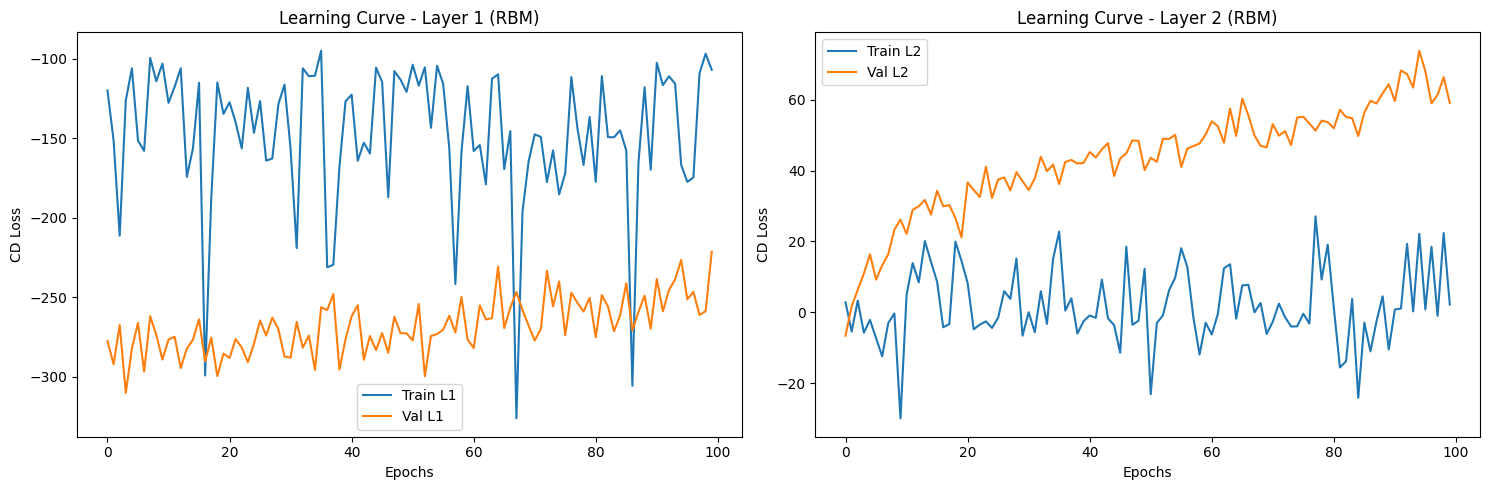

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Camada 1
    sns.lineplot(x=range(len(history['l1_train'])), y=history['l1_train'], ax=axes[0], label='Train L1')
    sns.lineplot(x=range(len(history['l1_val'])), y=history['l1_val'], ax=axes[0], label='Val L1')
    axes[0].set_title('Learning Curve - Layer 1 (RBM)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('CD Loss')
    
    # Camada 2
    sns.lineplot(x=range(len(history['l2_train'])), y=history['l2_train'], ax=axes[1], label='Train L2')
    sns.lineplot(x=range(len(history['l2_val'])), y=history['l2_val'], ax=axes[1], label='Val L2')
    axes[1].set_title('Learning Curve - Layer 2 (RBM)')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('CD Loss')
    
    plt.tight_layout()
    plt.savefig(f'dbm_learning_curves_T{T}_L{L}.png')
    plt.show()

# Chamada final
history = train_model(model, train_loader, val_loader, num_epochs=num_epochs)
plot_learning_curves(history)

### 1) ISING MODEL SIMULATOR TO COLECTING DATA FOR DBM code

Data saved as: ising_data/ising_configurations_T2.5_L128.npy


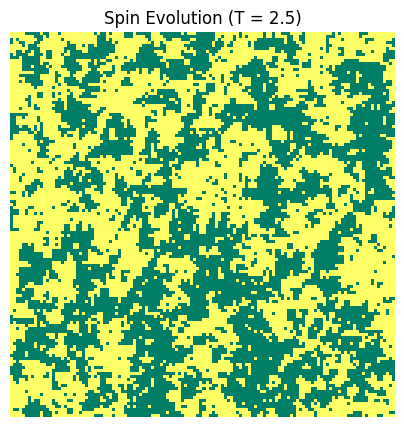

GIF saved as 'wolff_ising_simulation_T2.5_L128.gif'


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# Model parameters
L = 128  # lattice size
T = 2.5  # temperature
J = 1    # coupling constant

beta = 1 / T
p = 1 - np.exp(-2 * beta * J)
n_steps = 5000

# Generate random spin configuration on LxL lattice
spins = np.random.choice([-1, 1], size=(L, L))

# Function to select cross-shaped nearest neighbors
def neighbors(i, j, L):
    return [((i + 1) % L, j),
            ((i - 1) % L, j),
            (i, (j + 1) % L),
            (i, (j - 1) % L)]

# Wolff algorithm
def wolff_cluster_flip(spins, L, p):
    i, j = np.random.randint(0, L, size=2)
    cluster = {(i, j)}
    frontier = [(i, j)]
    original_spin = spins[i, j]
    while frontier:
        x, y = frontier.pop()
        for nx, ny in neighbors(x, y, L):
            if (nx, ny) not in cluster and spins[nx, ny] == original_spin:
                if np.random.rand() < p:
                    cluster.add((nx, ny))
                    frontier.append((nx, ny))
    for x, y in cluster:
        spins[x, y] *= -1
    return spins

# Initialize lists for GIF and final states
frames = []
final_state_samples = []
frame_interval = 30
save_interval = 25  # save a sample every 25 steps

# Main simulation loop
for step in range(n_steps):
    wolff_cluster_flip(spins, L, p)

    if step % frame_interval == 0:
        frames.append(spins.copy())

    if step > 3000 and step % save_interval == 0:
        final_state_samples.append(spins.copy())

# Save final samples as .npy file
output_path = "ising_data"
os.makedirs(output_path, exist_ok=True)
file_name = os.path.join(output_path, f"ising_configurations_T{T}_L{L}.npy")
np.save(file_name, np.array(final_state_samples))
print(f"Data saved as: {file_name}")

# Create and save animation GIF
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0], cmap="summer", animated=True)
ax.set_title(f"Spin Evolution (T = {T})")
plt.axis("off")

def update(frame):
    im.set_array(frames[frame])
    return [im]
ani = FuncAnimation(fig, update, frames=len(frames), interval=200, blit=True)
gif_path = f"wolff_ising_simulation_T{T}_L{L}.gif"
ani.save(gif_path, writer=PillowWriter(fps=5))
plt.show()
print(f"GIF saved as '{gif_path}'")


### 2) LIBRARIES FOR RBM AND DBM

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

### 3) RBM + DBM CODE & IMAGE PLOTING OF SIMULATION

Training for phase: critical
Pre-training layer 1...
Epoch 1 (layer 1), Loss: 168.9697
Epoch 2 (layer 1), Loss: -91.1820
Epoch 3 (layer 1), Loss: -410.4221
Epoch 4 (layer 1), Loss: -62.5624
Epoch 5 (layer 1), Loss: -288.4088
Epoch 6 (layer 1), Loss: -96.9609
Epoch 7 (layer 1), Loss: -62.0896
Epoch 8 (layer 1), Loss: -379.8781
Epoch 9 (layer 1), Loss: -353.0586
Epoch 10 (layer 1), Loss: -870.3337
Epoch 11 (layer 1), Loss: -714.0920
Epoch 12 (layer 1), Loss: -1008.3451
Epoch 13 (layer 1), Loss: -893.7961
Epoch 14 (layer 1), Loss: -1282.2793
Epoch 15 (layer 1), Loss: -1281.0542
Epoch 16 (layer 1), Loss: -783.5745
Epoch 17 (layer 1), Loss: -1808.6357
Epoch 18 (layer 1), Loss: -1555.2664
Epoch 19 (layer 1), Loss: -1036.9532
Epoch 20 (layer 1), Loss: -1054.9688
Epoch 21 (layer 1), Loss: -980.6180
Epoch 22 (layer 1), Loss: -1993.3652
Epoch 23 (layer 1), Loss: -2360.8877
Epoch 24 (layer 1), Loss: -938.0126
Epoch 25 (layer 1), Loss: -1130.8171
Epoch 26 (layer 1), Loss: -730.9775
Epoch 27 (layer

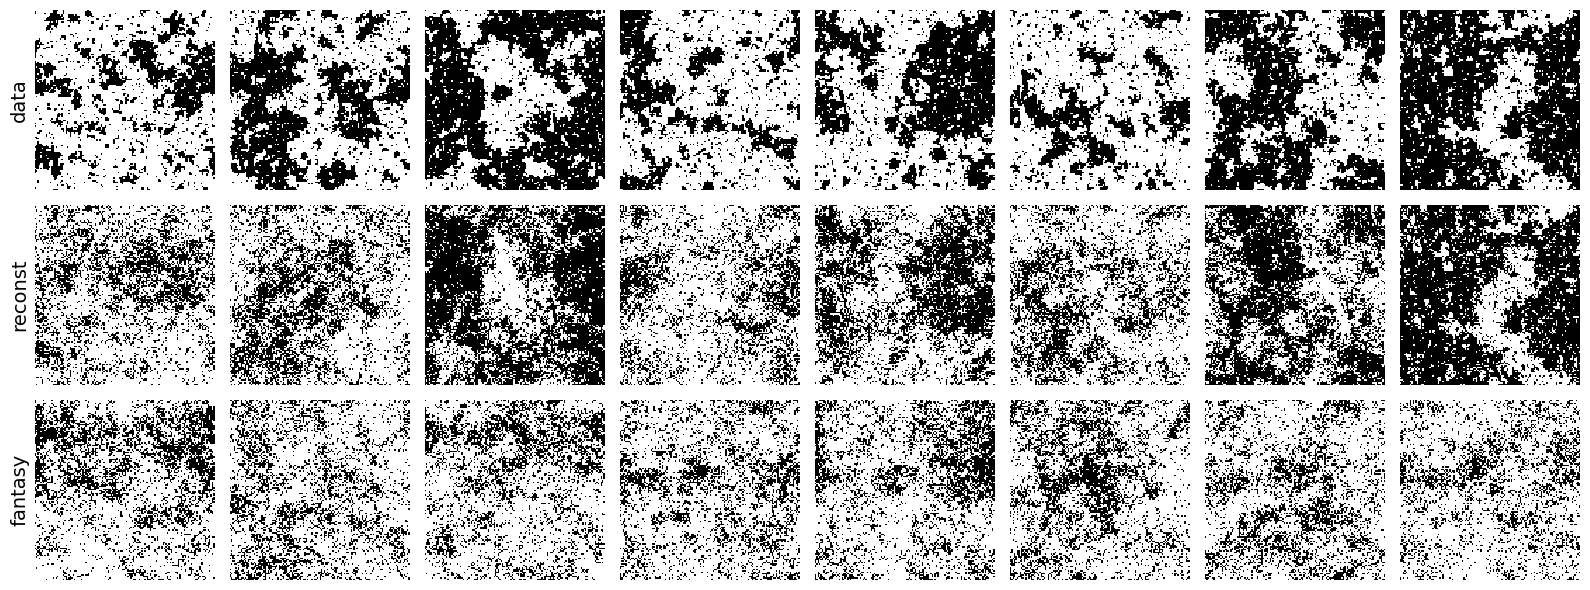

Saved in: ising_data/DBM_ising_training_data_T2.5_L=128.npy


In [16]:
# Grid size
L = 128
# Temperature
T = 2.5

# Grid parameters
image_shape = (L, L)
n_visible = L * L
num_to_plot = 8

batch_size = 15
num_epochs = 500
monte_carlo_steps = 5
num_fantasy_steps = 250
num_hidden_units = [1024, 64]  # Adjusted proportionally to L increase

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RBM class
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))

    def sample_h(self, v):
        prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return torch.bernoulli(prob), prob

    def sample_v(self, h):
        prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return torch.bernoulli(prob), prob

    def forward(self, v, k=1):
        v_k = v
        for _ in range(k):
            h_prob = torch.sigmoid(F.linear(v_k, self.W, self.h_bias))
            v_prob = torch.sigmoid(F.linear(h_prob, self.W.t(), self.v_bias))
            v_k = v_prob  # keep gradients
        return v, v_k

# Contrastive Divergence Loss - CORRIGIDO: adicionado termo h_bias faltante
def contrastive_divergence_loss(v0, vk, h0, hk, rbm):
    # Energia RBM completa: E = -v·W·h - v·v_bias - h·h_bias
    energy_vh_data = torch.matmul(v0, rbm.W.t()) * h0
    E_data = -torch.sum(energy_vh_data, dim=1) - torch.sum(v0 * rbm.v_bias, dim=1) - torch.sum(h0 * rbm.h_bias, dim=1)
    
    energy_vh_model = torch.matmul(vk, rbm.W.t()) * hk
    E_model = -torch.sum(energy_vh_model, dim=1) - torch.sum(vk * rbm.v_bias, dim=1) - torch.sum(hk * rbm.h_bias, dim=1)
    
    return torch.mean(E_data - E_model)

# Model training
def train_model(model, data_loader, num_epochs, steps):
    rbm1, rbm2 = model
    device = next(rbm1.parameters()).device
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.007)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    
    print("Pre-training layer 1...")
    rbm1.train()
    for epoch in range(num_epochs):
        for batch, in data_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad()
            loss.backward()
            optim1.step()
        print(f"Epoch {epoch+1} (layer 1), Loss: {loss.item():.4f}")

    print("Pre-training layer 2...")
    rbm2.train()
    with torch.no_grad():
        all_h, _ = rbm1.sample_h(torch.cat([b[0].to(device) for b in data_loader]))
    dataset_h = TensorDataset(all_h)
    loader_h = DataLoader(dataset_h, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        for batch, in loader_h:
            h0 = batch.to(device)
            h0_sample, _ = rbm2.sample_h(h0)
            vk, _ = rbm2.sample_v(h0_sample)
            hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_sample, hk, rbm2)
            optim2.zero_grad()
            loss.backward()
            optim2.step()
        print(f"Epoch {epoch+1} (layer 2), Loss: {loss.item():.4f}")

# Reconstruction and fantasies

def compute_reconstructions(rbm1, rbm2, data_tensor):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        h1_rec, _ = rbm2.sample_v(h2)
        v_rec, _ = rbm1.sample_v(h1_rec)
    return v_rec

# CORRIGIDO: Lógica do loop de amostagem alternada entre camadas
def compute_fantasy_particles(rbm1, rbm2, data_tensor, num_steps=num_fantasy_steps):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        for _ in range(num_steps):
            # Amostrar h1 (visível para rbm2) a partir de h2
            h1, _ = rbm2.sample_v(h2)
            # Amostrar v (visível para rbm1) a partir de h1
            v, _ = rbm1.sample_v(h1)
            # Amostrar h1 (oculto para rbm1) a partir de v
            h1, _ = rbm1.sample_h(v)
            # Amostrar h2 (oculto para rbm2) a partir de h1
            h2, _ = rbm2.sample_h(h1)
        v_gen, _ = rbm1.sample_v(h1)
    return v_gen.detach().cpu().numpy()

# Load dataset

def Load_Ising_Dataset(path='ising_data'):
    return {
        'critical': np.load(f"{path}/ising_configurations_T2.3_L128.npy")
    }

# Plotting

def plot_image_grid(image_array, shape, vmin=0, vmax=1, row_titles=None, filename=None):
    array = np.array(image_array)
    nrows, ncols = array.shape[:2]

    fig = plt.figure(figsize=(2 * ncols, 2 * nrows))
    grid = gridspec.GridSpec(nrows, ncols)

    for i in range(nrows):
        for j in range(ncols):
            ax = plt.subplot(grid[i, j])
            sns.heatmap(array[i][j].reshape(shape),
                        ax=ax,
                        cbar=False,
                        cmap='gray',
                        vmin=vmin,
                        vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
        if row_titles:
            ax = plt.subplot(grid[i, 0])
            ax.set_ylabel(row_titles[i], fontsize=14)

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()
    plt.close(fig)

# Main execution

data = Load_Ising_Dataset()

dbm_L1_reconstructions = {}
dbm_L1_fantasy = {}
true_examples = {}
dbm_models = {}

for phase in ['critical']:
    print(f"Training for phase: {phase}")

    X_phase = data[phase]
    X_phase = (X_phase > 0).astype(np.float32)
    X_phase = X_phase.reshape(X_phase.shape[0], -1)

    torch_data = torch.tensor(X_phase)
    dataset = TensorDataset(torch_data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    rbm1 = RBM(n_visible=n_visible, n_hidden=num_hidden_units[0]).to(device)
    rbm2 = RBM(n_visible=num_hidden_units[0], n_hidden=num_hidden_units[1]).to(device)
    model = [rbm1, rbm2]

    train_model(model, dataloader, num_epochs=num_epochs, steps=monte_carlo_steps)
    dbm_models[phase] = model

    samples = torch_data[:num_to_plot].to(device)
    v_rec = compute_reconstructions(rbm1, rbm2, samples)
    true_examples[phase] = samples.cpu().numpy()
    dbm_L1_reconstructions[phase] = v_rec.detach().cpu().numpy()

    samples_for_fantasy = torch_data[:num_to_plot].to(device)
    v_gen = compute_fantasy_particles(rbm1, rbm2, samples_for_fantasy, num_steps=num_fantasy_steps)
    dbm_L1_fantasy[phase] = v_gen

    plot_image_grid(
        np.array([
            true_examples[phase],
            dbm_L1_reconstructions[phase],
            dbm_L1_fantasy[phase]
        ]),
        shape=image_shape,
        vmin=0,
        vmax=1,
        row_titles=["data", "reconst", "fantasy"],
        filename=f"DBM_Ising-{phase}_L{L}.png"
    )

# Save all results
data_to_save = np.array([
    dbm_models, true_examples, dbm_L1_fantasy, dbm_L1_reconstructions,
    image_shape, num_to_plot, batch_size, num_epochs,
    monte_carlo_steps, num_fantasy_steps, num_hidden_units
], dtype=object)

save_file_name = f'ising_data/DBM_ising_training_data_T{T}_L={L}.npy'
np.save(save_file_name, data_to_save, allow_pickle=True)
print(f"Saved in: {save_file_name}")

## Now let's see if model is acting like it should

In [17]:
from sklearn.model_selection import train_test_split

# ... (após carregar X_phase)
X_train, X_val = train_test_split(X_phase, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=batch_size, shuffle=False)

In [18]:
def train_model(model, train_loader, val_loader, num_epochs):
    rbm1, rbm2 = model
    history = {'l1_train': [], 'l1_val': [], 'l2_train': [], 'l2_val': []}
    
    # --- TREINO CAMADA 1 ---
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.0001)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm1.train()
        for batch, in train_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad(); loss.backward(); optim1.step()
            train_loss += loss.item()
        
        # Validação Camada 1
        val_loss = 0
        rbm1.eval()
        with torch.no_grad():
            for batch, in val_loader:
                v0 = batch.to(device)
                h0, _ = rbm1.sample_h(v0); vk, _ = rbm1.sample_v(h0); hk, _ = rbm1.sample_h(vk)
                val_loss += contrastive_divergence_loss(v0, vk, h0, hk, rbm1).item()
        
        history['l1_train'].append(train_loss/len(train_loader))
        history['l1_val'].append(val_loss/len(val_loader))
        print(f"L1 Epoch {epoch+1}: Train Loss {history['l1_train'][-1]:.4f} | Val Loss {history['l1_val'][-1]:.4f}")

    # --- PREPARAÇÃO PARA CAMADA 2 ---
    # Obter representações ocultas da camada 1
    with torch.no_grad():
        train_h, _ = rbm1.sample_h(torch.tensor(X_train).to(device))
        val_h, _ = rbm1.sample_h(torch.tensor(X_val).to(device))
    
    loader_h_train = DataLoader(TensorDataset(train_h), batch_size=batch_size, shuffle=True)
    loader_h_val = DataLoader(TensorDataset(val_h), batch_size=batch_size, shuffle=False)

    # --- TREINO CAMADA 2 ---
    # A camada 2 recebe as ativações ocultas da camada 1 como sua entrada (visível)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm2.train()
        for batch, in loader_h_train:
            h0 = batch.to(device)  # h0 é a entrada visível para rbm2 (saída oculta de rbm1)
            h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2)
            optim2.zero_grad(); loss.backward(); optim2.step()
            train_loss += loss.item()

        val_loss = 0
        rbm2.eval()
        with torch.no_grad():
            for batch, in loader_h_val:
                h0 = batch.to(device)
                h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
                val_loss += contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2).item()

        history['l2_train'].append(train_loss/len(loader_h_train))
        history['l2_val'].append(val_loss/len(loader_h_val))
        print(f"L2 Epoch {epoch+1}: Train Loss {history['l2_train'][-1]:.4f} | Val Loss {history['l2_val'][-1]:.4f}")
    
    return history

L1 Epoch 1: Train Loss -1833.2849 | Val Loss -1966.5031
L1 Epoch 2: Train Loss -1835.2480 | Val Loss -1934.5615
L1 Epoch 3: Train Loss -1976.5490 | Val Loss -1931.7551
L1 Epoch 4: Train Loss -2026.0218 | Val Loss -2018.4114
L1 Epoch 5: Train Loss -1902.9587 | Val Loss -1976.5513
L1 Epoch 6: Train Loss -1918.9455 | Val Loss -2079.8052
L1 Epoch 7: Train Loss -1988.8893 | Val Loss -2007.2258
L1 Epoch 8: Train Loss -1916.6606 | Val Loss -1930.5976
L1 Epoch 9: Train Loss -1980.5904 | Val Loss -1988.1396
L1 Epoch 10: Train Loss -1962.8628 | Val Loss -1996.2510
L1 Epoch 11: Train Loss -1895.2999 | Val Loss -1971.2812
L1 Epoch 12: Train Loss -1987.2613 | Val Loss -1928.8049
L1 Epoch 13: Train Loss -1998.6026 | Val Loss -1960.1996
L1 Epoch 14: Train Loss -1896.9174 | Val Loss -1984.6208
L1 Epoch 15: Train Loss -1991.0250 | Val Loss -1989.2441
L1 Epoch 16: Train Loss -1942.4103 | Val Loss -2018.4476
L1 Epoch 17: Train Loss -1923.3134 | Val Loss -1949.9325
L1 Epoch 18: Train Loss -1970.0890 | Val

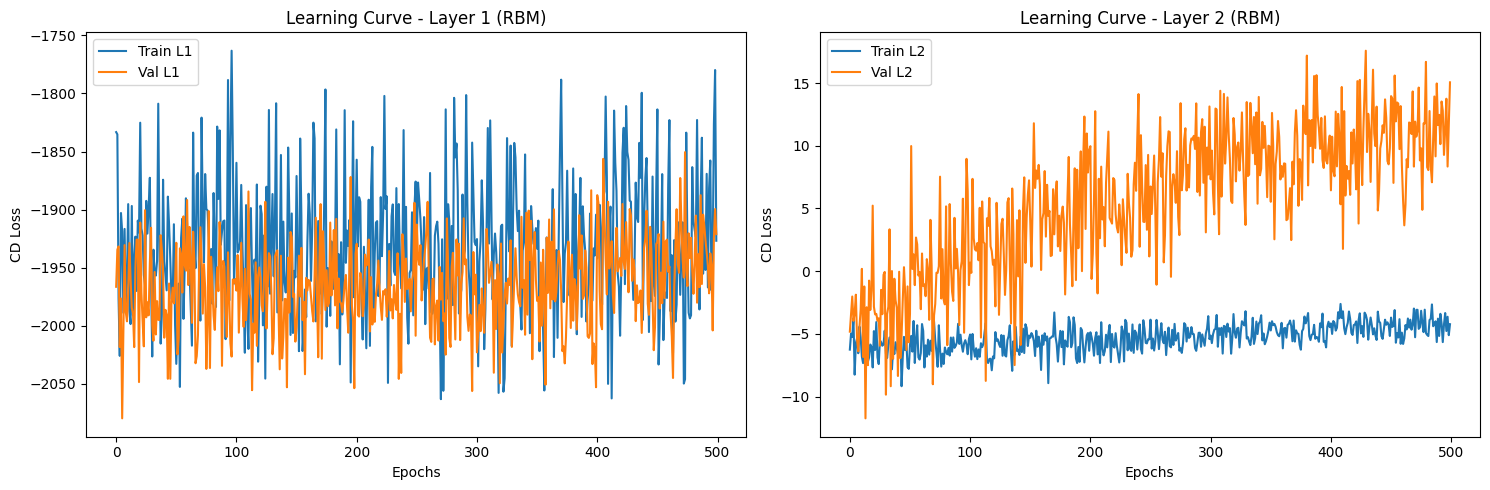

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Camada 1
    sns.lineplot(x=range(len(history['l1_train'])), y=history['l1_train'], ax=axes[0], label='Train L1')
    sns.lineplot(x=range(len(history['l1_val'])), y=history['l1_val'], ax=axes[0], label='Val L1')
    axes[0].set_title('Learning Curve - Layer 1 (RBM)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('CD Loss')
    
    # Camada 2
    sns.lineplot(x=range(len(history['l2_train'])), y=history['l2_train'], ax=axes[1], label='Train L2')
    sns.lineplot(x=range(len(history['l2_val'])), y=history['l2_val'], ax=axes[1], label='Val L2')
    axes[1].set_title('Learning Curve - Layer 2 (RBM)')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('CD Loss')
    
    plt.tight_layout()
    plt.savefig(f'dbm_learning_curves_T{T}_L{L}.png')
    plt.show()

# Chamada final
history = train_model(model, train_loader, val_loader, num_epochs=num_epochs)
plot_learning_curves(history)

In [7]:
print(rbm1.W.max())

tensor(5.9171, device='cuda:0', grad_fn=<MaxBackward1>)


# T = 4.0

Data saved as: ising_data/ising_configurations_T4.0_L128.npy


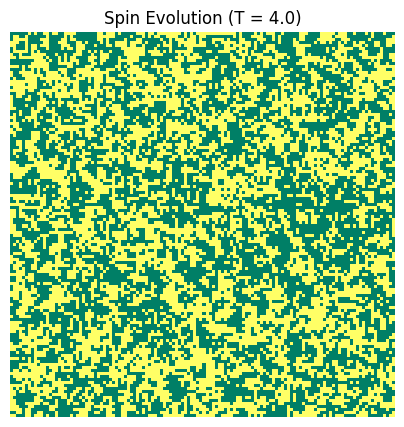

GIF saved as 'wolff_ising_simulation_T4.0_L128.gif'


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# Model parameters
L = 128  # lattice size
T = 4.0  # temperature
J = 1    # coupling constant

beta = 1 / T
p = 1 - np.exp(-2 * beta * J)
n_steps = 5000

# Generate random spin configuration on LxL lattice
spins = np.random.choice([-1, 1], size=(L, L))

# Function to select cross-shaped nearest neighbors
def neighbors(i, j, L):
    return [((i + 1) % L, j),
            ((i - 1) % L, j),
            (i, (j + 1) % L),
            (i, (j - 1) % L)]

# Wolff algorithm
def wolff_cluster_flip(spins, L, p):
    i, j = np.random.randint(0, L, size=2)
    cluster = {(i, j)}
    frontier = [(i, j)]
    original_spin = spins[i, j]
    while frontier:
        x, y = frontier.pop()
        for nx, ny in neighbors(x, y, L):
            if (nx, ny) not in cluster and spins[nx, ny] == original_spin:
                if np.random.rand() < p:
                    cluster.add((nx, ny))
                    frontier.append((nx, ny))
    for x, y in cluster:
        spins[x, y] *= -1
    return spins

# Initialize lists for GIF and final states
frames = []
final_state_samples = []
frame_interval = 30
save_interval = 25  # save a sample every 25 steps

# Main simulation loop
for step in range(n_steps):
    wolff_cluster_flip(spins, L, p)

    if step % frame_interval == 0:
        frames.append(spins.copy())

    if step > 3000 and step % save_interval == 0:
        final_state_samples.append(spins.copy())

# Save final samples as .npy file
output_path = "ising_data"
os.makedirs(output_path, exist_ok=True)
file_name = os.path.join(output_path, f"ising_configurations_T{T}_L{L}.npy")
np.save(file_name, np.array(final_state_samples))
print(f"Data saved as: {file_name}")

# Create and save animation GIF
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0], cmap="summer", animated=True)
ax.set_title(f"Spin Evolution (T = {T})")
plt.axis("off")

def update(frame):
    im.set_array(frames[frame])
    return [im]
ani = FuncAnimation(fig, update, frames=len(frames), interval=200, blit=True)
gif_path = f"wolff_ising_simulation_T{T}_L{L}.gif"
ani.save(gif_path, writer=PillowWriter(fps=5))
plt.show()
print(f"GIF saved as '{gif_path}'")

Training for phase: critical
Pre-training layer 1...
Epoch 1 (layer 1), Loss: 2227.5469
Epoch 2 (layer 1), Loss: 2982.7930
Epoch 3 (layer 1), Loss: 1645.0938
Epoch 4 (layer 1), Loss: 2582.3672
Epoch 5 (layer 1), Loss: 1811.9102
Epoch 6 (layer 1), Loss: 916.7695
Epoch 7 (layer 1), Loss: 1239.5508
Epoch 8 (layer 1), Loss: 1112.1133
Epoch 9 (layer 1), Loss: 954.2500
Epoch 10 (layer 1), Loss: 302.1875
Epoch 11 (layer 1), Loss: 2611.4219
Epoch 12 (layer 1), Loss: 1099.4336
Epoch 13 (layer 1), Loss: 805.3789
Epoch 14 (layer 1), Loss: 1382.3516
Epoch 15 (layer 1), Loss: 1498.6133
Epoch 16 (layer 1), Loss: 1148.3008
Epoch 17 (layer 1), Loss: 754.1484
Epoch 18 (layer 1), Loss: 1782.9844
Epoch 19 (layer 1), Loss: 1348.1602
Epoch 20 (layer 1), Loss: 1945.8906
Epoch 21 (layer 1), Loss: 2750.9922
Epoch 22 (layer 1), Loss: 1745.1367
Epoch 23 (layer 1), Loss: 2429.8555
Epoch 24 (layer 1), Loss: 2983.7422
Epoch 25 (layer 1), Loss: 1517.1953
Epoch 26 (layer 1), Loss: 773.8086
Epoch 27 (layer 1), Loss: 

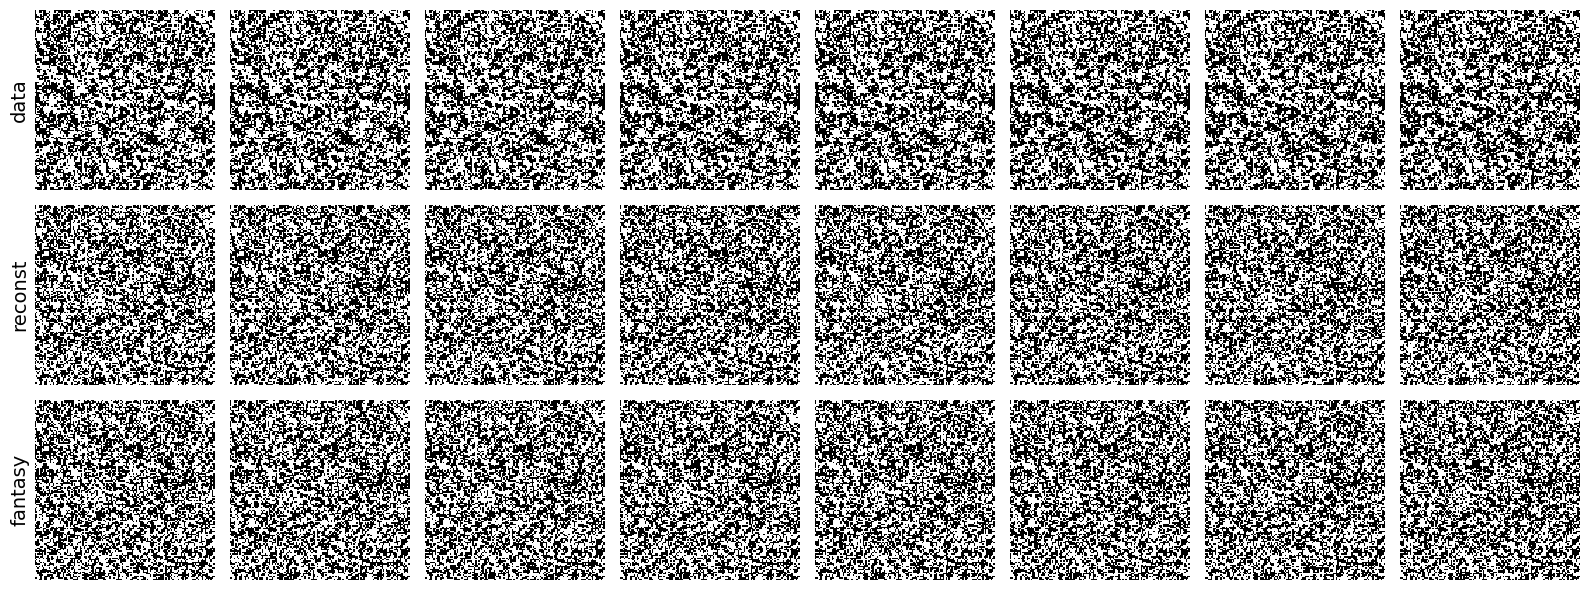

Saved in: ising_data/DBM_ising_training_data_T4.0_L=128.npy


In [21]:
# Grid size
L = 128

# Grid parameters
image_shape = (L, L)
n_visible = L * L
num_to_plot = 8

batch_size = 15
num_epochs = 500
monte_carlo_steps = 5
num_fantasy_steps = 250
num_hidden_units = [1024, 64]  # Adjusted proportionally to L increase

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RBM class
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))

    def sample_h(self, v):
        prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return torch.bernoulli(prob), prob

    def sample_v(self, h):
        prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return torch.bernoulli(prob), prob

    def forward(self, v, k=1):
        v_k = v
        for _ in range(k):
            h_prob = torch.sigmoid(F.linear(v_k, self.W, self.h_bias))
            v_prob = torch.sigmoid(F.linear(h_prob, self.W.t(), self.v_bias))
            v_k = v_prob  # keep gradients
        return v, v_k

# Contrastive Divergence Loss - CORRIGIDO: adicionado termo h_bias faltante
def contrastive_divergence_loss(v0, vk, h0, hk, rbm):
    # Energia RBM completa: E = -v·W·h - v·v_bias - h·h_bias
    energy_vh_data = torch.matmul(v0, rbm.W.t()) * h0
    E_data = -torch.sum(energy_vh_data, dim=1) - torch.sum(v0 * rbm.v_bias, dim=1) - torch.sum(h0 * rbm.h_bias, dim=1)
    
    energy_vh_model = torch.matmul(vk, rbm.W.t()) * hk
    E_model = -torch.sum(energy_vh_model, dim=1) - torch.sum(vk * rbm.v_bias, dim=1) - torch.sum(hk * rbm.h_bias, dim=1)
    
    return torch.mean(E_data - E_model)

# Model training
def train_model(model, data_loader, num_epochs, steps):
    rbm1, rbm2 = model
    device = next(rbm1.parameters()).device
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.007)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    
    print("Pre-training layer 1...")
    rbm1.train()
    for epoch in range(num_epochs):
        for batch, in data_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad()
            loss.backward()
            optim1.step()
        print(f"Epoch {epoch+1} (layer 1), Loss: {loss.item():.4f}")

    print("Pre-training layer 2...")
    rbm2.train()
    with torch.no_grad():
        all_h, _ = rbm1.sample_h(torch.cat([b[0].to(device) for b in data_loader]))
    dataset_h = TensorDataset(all_h)
    loader_h = DataLoader(dataset_h, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        for batch, in loader_h:
            h0 = batch.to(device)
            h0_sample, _ = rbm2.sample_h(h0)
            vk, _ = rbm2.sample_v(h0_sample)
            hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_sample, hk, rbm2)
            optim2.zero_grad()
            loss.backward()
            optim2.step()
        print(f"Epoch {epoch+1} (layer 2), Loss: {loss.item():.4f}")

# Reconstruction and fantasies

def compute_reconstructions(rbm1, rbm2, data_tensor):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        h1_rec, _ = rbm2.sample_v(h2)
        v_rec, _ = rbm1.sample_v(h1_rec)
    return v_rec

# CORRIGIDO: Lógica do loop de amostagem alternada entre camadas
def compute_fantasy_particles(rbm1, rbm2, data_tensor, num_steps=num_fantasy_steps):
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        for _ in range(num_steps):
            # Amostrar h1 (visível para rbm2) a partir de h2
            h1, _ = rbm2.sample_v(h2)
            # Amostrar v (visível para rbm1) a partir de h1
            v, _ = rbm1.sample_v(h1)
            # Amostrar h1 (oculto para rbm1) a partir de v
            h1, _ = rbm1.sample_h(v)
            # Amostrar h2 (oculto para rbm2) a partir de h1
            h2, _ = rbm2.sample_h(h1)
        v_gen, _ = rbm1.sample_v(h1)
    return v_gen.detach().cpu().numpy()

# Load dataset

def Load_Ising_Dataset(path='ising_data'):
    return {
        'critical': np.load(f"{path}/ising_configurations_T4.0_L128.npy")
    }

# Plotting

def plot_image_grid(image_array, shape, vmin=0, vmax=1, row_titles=None, filename=None):
    array = np.array(image_array)
    nrows, ncols = array.shape[:2]

    fig = plt.figure(figsize=(2 * ncols, 2 * nrows))
    grid = gridspec.GridSpec(nrows, ncols)

    for i in range(nrows):
        for j in range(ncols):
            ax = plt.subplot(grid[i, j])
            sns.heatmap(array[i][j].reshape(shape),
                        ax=ax,
                        cbar=False,
                        cmap='gray',
                        vmin=vmin,
                        vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
        if row_titles:
            ax = plt.subplot(grid[i, 0])
            ax.set_ylabel(row_titles[i], fontsize=14)

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()
    plt.close(fig)

# Main execution

data = Load_Ising_Dataset()

dbm_L1_reconstructions = {}
dbm_L1_fantasy = {}
true_examples = {}
dbm_models = {}

for phase in ['critical']:
    print(f"Training for phase: {phase}")

    X_phase = data[phase]
    X_phase = (X_phase > 0).astype(np.float32)
    X_phase = X_phase.reshape(X_phase.shape[0], -1)

    torch_data = torch.tensor(X_phase)
    dataset = TensorDataset(torch_data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    rbm1 = RBM(n_visible=n_visible, n_hidden=num_hidden_units[0]).to(device)
    rbm2 = RBM(n_visible=num_hidden_units[0], n_hidden=num_hidden_units[1]).to(device)
    model = [rbm1, rbm2]

    train_model(model, dataloader, num_epochs=num_epochs, steps=monte_carlo_steps)
    dbm_models[phase] = model

    samples = torch_data[:num_to_plot].to(device)
    v_rec = compute_reconstructions(rbm1, rbm2, samples)
    true_examples[phase] = samples.cpu().numpy()
    dbm_L1_reconstructions[phase] = v_rec.detach().cpu().numpy()

    samples_for_fantasy = torch_data[:num_to_plot].to(device)
    v_gen = compute_fantasy_particles(rbm1, rbm2, samples_for_fantasy, num_steps=num_fantasy_steps)
    dbm_L1_fantasy[phase] = v_gen

    plot_image_grid(
        np.array([
            true_examples[phase],
            dbm_L1_reconstructions[phase],
            dbm_L1_fantasy[phase]
        ]),
        shape=image_shape,
        vmin=0,
        vmax=1,
        row_titles=["data", "reconst", "fantasy"],
        filename=f"DBM_Ising-{phase}_L{L}.png"
    )

# Save all results
data_to_save = np.array([
    dbm_models, true_examples, dbm_L1_fantasy, dbm_L1_reconstructions,
    image_shape, num_to_plot, batch_size, num_epochs,
    monte_carlo_steps, num_fantasy_steps, num_hidden_units
], dtype=object)

save_file_name = f'ising_data/DBM_ising_training_data_T{T}_L={L}.npy'
np.save(save_file_name, data_to_save, allow_pickle=True)
print(f"Saved in: {save_file_name}")

In [22]:
from sklearn.model_selection import train_test_split

# ... (após carregar X_phase)
X_train, X_val = train_test_split(X_phase, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=batch_size, shuffle=False)

def train_model(model, train_loader, val_loader, num_epochs):
    rbm1, rbm2 = model
    history = {'l1_train': [], 'l1_val': [], 'l2_train': [], 'l2_val': []}
    
    # --- TREINO CAMADA 1 ---
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=0.0001)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm1.train()
        for batch, in train_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad(); loss.backward(); optim1.step()
            train_loss += loss.item()
        
        # Validação Camada 1
        val_loss = 0
        rbm1.eval()
        with torch.no_grad():
            for batch, in val_loader:
                v0 = batch.to(device)
                h0, _ = rbm1.sample_h(v0); vk, _ = rbm1.sample_v(h0); hk, _ = rbm1.sample_h(vk)
                val_loss += contrastive_divergence_loss(v0, vk, h0, hk, rbm1).item()
        
        history['l1_train'].append(train_loss/len(train_loader))
        history['l1_val'].append(val_loss/len(val_loader))
        print(f"L1 Epoch {epoch+1}: Train Loss {history['l1_train'][-1]:.4f} | Val Loss {history['l1_val'][-1]:.4f}")

    # --- PREPARAÇÃO PARA CAMADA 2 ---
    # Obter representações ocultas da camada 1
    with torch.no_grad():
        train_h, _ = rbm1.sample_h(torch.tensor(X_train).to(device))
        val_h, _ = rbm1.sample_h(torch.tensor(X_val).to(device))
    
    loader_h_train = DataLoader(TensorDataset(train_h), batch_size=batch_size, shuffle=True)
    loader_h_val = DataLoader(TensorDataset(val_h), batch_size=batch_size, shuffle=False)

    # --- TREINO CAMADA 2 ---
    # A camada 2 recebe as ativações ocultas da camada 1 como sua entrada (visível)
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=0.007)
    for epoch in range(num_epochs):
        train_loss = 0
        rbm2.train()
        for batch, in loader_h_train:
            h0 = batch.to(device)  # h0 é a entrada visível para rbm2 (saída oculta de rbm1)
            h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2)
            optim2.zero_grad(); loss.backward(); optim2.step()
            train_loss += loss.item()

        val_loss = 0
        rbm2.eval()
        with torch.no_grad():
            for batch, in loader_h_val:
                h0 = batch.to(device)
                h0_s, _ = rbm2.sample_h(h0); vk, _ = rbm2.sample_v(h0_s); hk, _ = rbm2.sample_h(vk)
                val_loss += contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2).item()

        history['l2_train'].append(train_loss/len(loader_h_train))
        history['l2_val'].append(val_loss/len(loader_h_val))
        print(f"L2 Epoch {epoch+1}: Train Loss {history['l2_train'][-1]:.4f} | Val Loss {history['l2_val'][-1]:.4f}")
    
    return history

L1 Epoch 1: Train Loss 1534.1582 | Val Loss 916.0724
L1 Epoch 2: Train Loss 1053.7693 | Val Loss 643.9964
L1 Epoch 3: Train Loss 977.8867 | Val Loss 432.7589
L1 Epoch 4: Train Loss 911.6361 | Val Loss 255.9021
L1 Epoch 5: Train Loss 708.5440 | Val Loss 113.9386
L1 Epoch 6: Train Loss 487.3027 | Val Loss -40.5880
L1 Epoch 7: Train Loss 455.2488 | Val Loss -103.3114
L1 Epoch 8: Train Loss 338.8571 | Val Loss -144.8536
L1 Epoch 9: Train Loss 270.2569 | Val Loss -223.7719
L1 Epoch 10: Train Loss 231.8098 | Val Loss -216.4792
L1 Epoch 11: Train Loss 254.5152 | Val Loss -217.5203
L1 Epoch 12: Train Loss 87.1975 | Val Loss -222.9406
L1 Epoch 13: Train Loss 121.6675 | Val Loss -223.1640
L1 Epoch 14: Train Loss 113.5913 | Val Loss -203.2698
L1 Epoch 15: Train Loss 107.5323 | Val Loss -245.5729
L1 Epoch 16: Train Loss 87.4777 | Val Loss -273.5984
L1 Epoch 17: Train Loss 120.4465 | Val Loss -265.6812
L1 Epoch 18: Train Loss 260.6917 | Val Loss -306.8115
L1 Epoch 19: Train Loss 12.2944 | Val Loss 

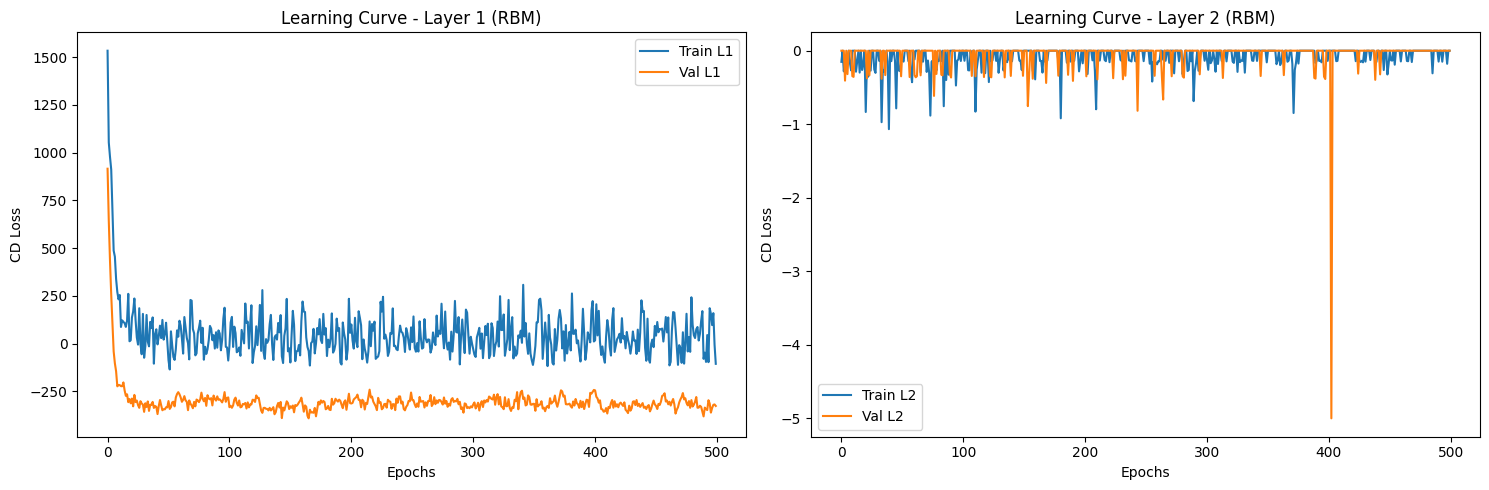

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Camada 1
    sns.lineplot(x=range(len(history['l1_train'])), y=history['l1_train'], ax=axes[0], label='Train L1')
    sns.lineplot(x=range(len(history['l1_val'])), y=history['l1_val'], ax=axes[0], label='Val L1')
    axes[0].set_title('Learning Curve - Layer 1 (RBM)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('CD Loss')
    
    # Camada 2
    sns.lineplot(x=range(len(history['l2_train'])), y=history['l2_train'], ax=axes[1], label='Train L2')
    sns.lineplot(x=range(len(history['l2_val'])), y=history['l2_val'], ax=axes[1], label='Val L2')
    axes[1].set_title('Learning Curve - Layer 2 (RBM)')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('CD Loss')
    
    plt.tight_layout()
    plt.savefig(f'dbm_learning_curves_T{T}_L{L}.png')
    plt.show()

# Chamada final
history = train_model(model, train_loader, val_loader, num_epochs=num_epochs)
plot_learning_curves(history)